Using `heart.csv` as our dataset

## 1. Setup

In [52]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform


from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    recall_score
)



In [53]:
# config.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RADNOM_STATE = 42
CSV_PATH = "/Users/pouniq/HeartDiseasePrediction/Data/heart.csv"
TARGET_COL = 'target'


In [54]:
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [56]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

`categorical` columns are encoded 

## 2. EDA

In [57]:
num_cols = ['age','trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']
print(num_cols)
print(cat_cols)

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [58]:
# missing values
df.isna().sum().sort_values()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [59]:
for col in df.columns:
    print(df[col].value_counts().head(10))

age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
Name: count, dtype: int64
sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
Name: count, dtype: int64
chol
204    21
234    21
197    19
212    18
254    17
269    16
177    14
240    14
282    14
239    13
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
thalach
162    35
160    31
163    29
173    28
152    28
144    26
132    26
150    25
125    25
143    23
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
oldpeak
0.000    329
1.200     58
1.000     51
0.600     47
0.800     44
1.400     44
1.600     37
0.200     37
1.800     36
2.000     32
Name: count, dtype: int64
slope
1    482
2    469
0     74
N

In [60]:
df.duplicated().sum()


np.int64(723)

we have alot of duplicates, to ensure that we prevent from data leakage we consider to use `GroupShuffleSplit`.

In [61]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200
ca,1025.000,0.754,1.031,0.000,0.000,0.000,1.000,4.000


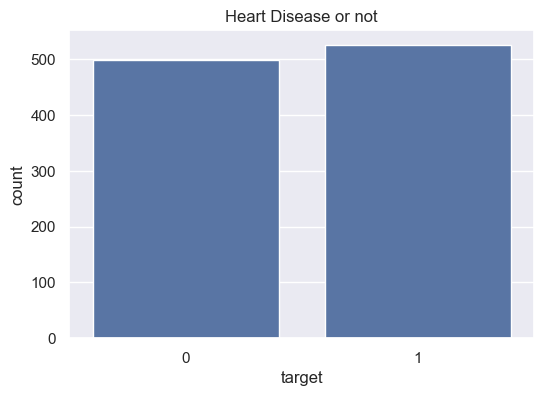

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x = TARGET_COL, data=df)
plt.title('Heart Disease or not')
plt.show()

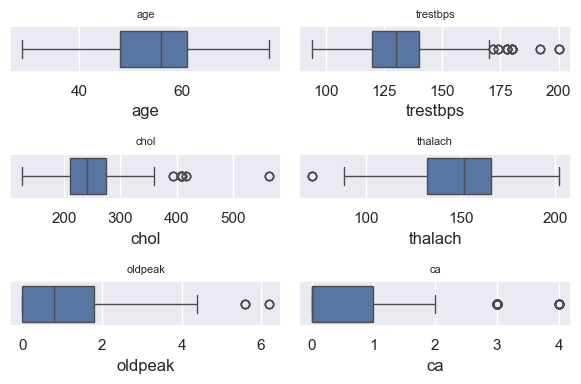

In [63]:
fig, axes = plt.subplots(3,2,figsize = (6,4))
axes = axes.flatten()


for i,col in enumerate(num_cols):
    sns.boxplot(x = df[col], ax = axes[i])
    axes[i].set_title(col, fontsize = 8)
plt.tight_layout()
plt.show()
    

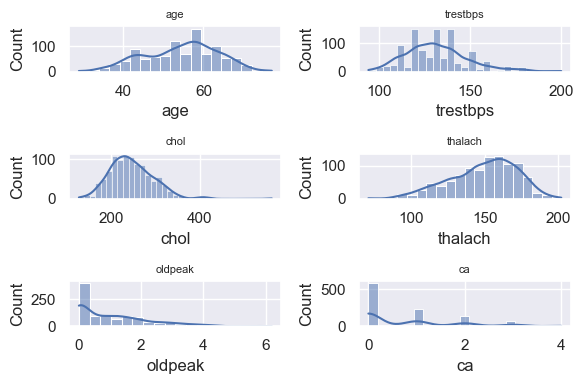

In [64]:
fig, axes = plt.subplots(3,2,figsize = (6,4))
axes = axes.flatten()


for i,col in enumerate(num_cols):
    sns.histplot(df[col],kde=True, ax = axes[i])
    axes[i].set_title(col, fontsize = 8)
plt.tight_layout()
plt.show()

<Axes: >

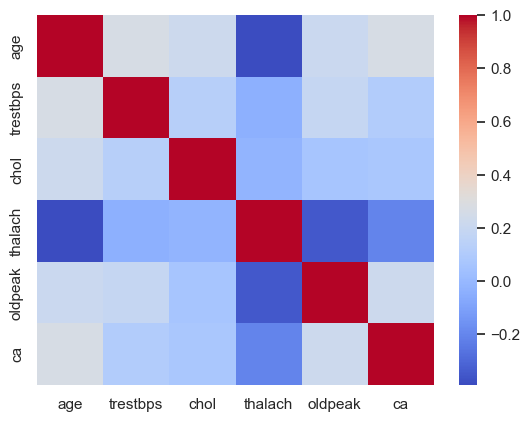

In [65]:
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')

## 3. Data Preprocessing

In [66]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

**this part is where we are trying to prevent data leakage because of duplicates we have inside our dataset**


*maybe people just are alike and have the same values as a patient*

In [67]:
# create a signature for each row
# it will create a hash value meaning that if two rows have the same values 
# the hash value will be the same

row_sig = pd.util.hash_pandas_object(X, index=False)
row_sig

0         227725699829427419
1          50836151723211046
2       10894799888851965450
3        7685467519808865474
4        7567925198380305935
                ...         
1020     3225181974515146756
1021    18154997444670469537
1022     5193280767241158862
1023     6006013119690573124
1024    18087355452203249959
Length: 1025, dtype: uint64

In [68]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RADNOM_STATE
)

train_idx, test_idx = next(gss.split(X, y, groups=row_sig))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(869, 13) (156, 13)
(869,) (156,)


## 4. Logistic Regression

**baseline model in place**

In [69]:
base_pip = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

base_pip.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [70]:
y_pred_train = base_pip.predict(X_train)
y_pred = base_pip.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred)
print(acc_train)
print(acc_test)

0.8423475258918297
0.8333333333333334


In [71]:
def evaluate_cls(model,X_train,X_test,y_train, y_test, model_name):
    
    # predict
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    # accuracy
    train_acc = accuracy_score(y_train_pred, y_train)
    test_acc = accuracy_score(y_pred, y_test)
    
    # 
    print(model_name,'|',train_acc, test_acc)
    
    print('-'*100)
    
    print('train cls report')
    print(classification_report(y_train, y_train_pred))
   
    print('-'*100) 
    
    
    print('test cls report')
    print(classification_report(y_test, y_pred))
    
    

In [72]:
evaluate_cls(base_pip, X_train, X_test,y_train,y_test,'Logistic Regression')

Logistic Regression | 0.8423475258918297 0.8333333333333334
----------------------------------------------------------------------------------------------------
train cls report
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       430
           1       0.81      0.89      0.85       439

    accuracy                           0.84       869
   macro avg       0.85      0.84      0.84       869
weighted avg       0.85      0.84      0.84       869

----------------------------------------------------------------------------------------------------
test cls report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



## 5. Model Selection

In [79]:
models = {
    'LogisticReg': LogisticRegression(random_state=RADNOM_STATE, max_iter=1200),
    'SVM': SVC(random_state=RADNOM_STATE),
    'RF': RandomForestClassifier(random_state=RADNOM_STATE),
    'xgboost': XGBClassifier()
}

In [80]:
groups = pd.util.hash_pandas_object(X_train, index=False)
k = 5
cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=RADNOM_STATE)

In [86]:
for name, model in models.items():
    print(f'train for {name} model')
    model.fit(X_train, y_train)
    
    recall_scores = []
    f1_scores = []
    
    for tr_idx, te_idx in cv.split(X_train, y_train, groups=groups):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]
        
        Pipe = Pipeline(
            [
                ('scaler', StandardScaler()),
                ('model', model)
            ]
        )
        
        Pipe.fit(X_tr, y_tr)
        pred = Pipe.predict(X_te)
        
        
        recall_scores.append(recall_score(y_te, pred))
        f1_scores.append(f1_score(y_te, pred))


    print(f'model {model}')
    print('recall', recall_scores),
    print('f1', f1_scores)
    print('-'*20)
    print('mean recall', np.mean(recall_scores))
    print('mean f1', np.mean(f1_scores))
    print('-'*100)

    
    
    

train for LogisticReg model
model LogisticRegression(max_iter=1200, random_state=42)
recall [0.896551724137931, 0.7528089887640449, 0.9310344827586207, 0.8876404494382022, 0.8160919540229885]
f1 [0.8666666666666667, 0.7528089887640449, 0.9101123595505618, 0.8186528497409327, 0.7473684210526316]
--------------------
mean recall 0.8568255198243575
mean f1 0.8191218571549677
----------------------------------------------------------------------------------------------------
train for SVM model
model SVC(random_state=42)
recall [0.7931034482758621, 0.7191011235955056, 0.8160919540229885, 0.9550561797752809, 0.7241379310344828]
f1 [0.7624309392265194, 0.7619047619047619, 0.8352941176470589, 0.8333333333333334, 0.6923076923076923]
--------------------
mean recall 0.801498127340824
mean f1 0.7770541688838731
----------------------------------------------------------------------------------------------------
train for RF model
model RandomForestClassifier(random_state=42)
recall [0.93103448275

### HyperParameter Tuning

In [ ]:
Pipe_rfc = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=RADNOM_STATE, n_jobs=-1))
    ]
)

In [107]:
param_grid = {
    'model__n_estimators': randint(400,1200),
    'model__max_depth': [3,4,5,6],
    'model__min_samples_split': randint(10, 40),
    'model__min_samples_leaf': randint(4,20) ,
    'model__max_features': [0.25,0.35, 0.5, 'sqrt'],
    'model__bootstrap': [True],
    'model__max_samples': uniform(0.35, 0.6),
    'model__ccp_alpha': uniform(0.0, 0.02)
}

In [108]:
random_search = RandomizedSearchCV(
    estimator=Pipe_rfc,
    n_jobs=-1,
    n_iter=60,
    param_distributions=param_grid,
    verbose=2,
    random_state=RADNOM_STATE,
    cv = cv,
    scoring='f1_macro'
    
)

In [109]:
random_search.fit(X_train, y_train, groups=groups)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END model__bootstrap=True, model__ccp_alpha=0.00749080237694725, model__max_depth=3, model__max_features=0.5, model__max_samples=0.789196365086843, model__min_samples_leaf=16, model__min_samples_split=30, model__n_estimators=1014; total time=   4.0s
[CV] END model__bootstrap=True, model__ccp_alpha=0.00749080237694725, model__max_depth=3, model__max_features=0.5, model__max_samples=0.789196365086843, model__min_samples_leaf=16, model__min_samples_split=30, model__n_estimators=1014; total time=   4.1s
[CV] END model__bootstrap=True, model__ccp_alpha=0.00749080237694725, model__max_depth=3, model__max_features=0.5, model__max_samples=0.789196365086843, model__min_samples_leaf=16, model__min_samples_split=30, model__n_estimators=1014; total time=   4.1s
[CV] END model__bootstrap=True, model__ccp_alpha=0.00749080237694725, model__max_depth=3, model__max_features=0.5, model__max_samples=0.789196365086843, model__min_samples_l

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....t 0x1230aeeb0>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [110]:
random_search.best_params_

{'model__bootstrap': True,
 'model__ccp_alpha': np.float64(0.004744981749936002),
 'model__max_depth': 3,
 'model__max_features': 'sqrt',
 'model__max_samples': np.float64(0.7978948430708144),
 'model__min_samples_leaf': 19,
 'model__min_samples_split': 17,
 'model__n_estimators': 534}

In [112]:
random_search.best_score_
# now it is much more reliable

np.float64(0.8494369540284499)

### train the with (best) hyperParameters

In [130]:
best_rfc_pip = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            ccp_alpha=random_search.best_params_['model__ccp_alpha'],
            max_depth=random_search.best_params_['model__max_depth'],
            max_features=random_search.best_params_['model__max_features'],
            max_samples=random_search.best_params_['model__max_samples'],
            min_samples_leaf=random_search.best_params_['model__min_samples_leaf'],
            min_samples_split=random_search.best_params_['model__min_samples_split'],
            n_estimators=random_search.best_params_['model__n_estimators'],
            bootstrap=random_search.best_params_['model__bootstrap']
        ))
    ]
)

In [131]:
best_rfc_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",534
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",17


In [132]:
evaluate_cls(best_rfc_pipe,X_train,X_test, y_train, y_test, 'RandomForest')

RandomForest | 0.8791714614499425 0.8333333333333334
----------------------------------------------------------------------------------------------------
train cls report
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       430
           1       0.84      0.94      0.89       439

    accuracy                           0.88       869
   macro avg       0.88      0.88      0.88       869
weighted avg       0.88      0.88      0.88       869

----------------------------------------------------------------------------------------------------
test cls report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



In [133]:
test0 = X_train.iloc[25].tolist()

In [137]:
def predic_heart_disease(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns= X_train.columns
    )
    prediction = best_rfc_pipe.predict(input_df)[0]
    probab = best_rfc_pipe.predict_proba(input_df)[0][1]
    
    print(prediction)
    print(probab)
    
    
    if prediction == 1:
        print('you have heart disease')
    else:
        print('You are OK')
    return prediction, probab

In [138]:
predic_heart_disease(test0)

0
0.2826905127440934
You are OK


(np.int64(0), np.float64(0.2826905127440934))